# Standard Transformer Baseline


given the past 168 hours of POWER + 12 NWP variables, forecast the next 24
hours of POWER. 

In [1]:
import sys, math, random
sys.path.insert(0, "/Users/lin_/Solar_Prediction")   # make `src` importable
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11, 4)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", device)

torch 2.7.1 | device: mps


## 1. Data

Built with `GEFComTask15().load().deaccumulate()` so the four accumulated NWP
fields (daily-cumulative radiation/precipitation) are replaced by their true
hourly increments (`*_dea`), which is the physically meaningful driver of solar
power. The leakage-safe `time_split` from `src/helper` splits each zone 70/15/15
by time; windows stay within a segment. Input features are standardized with
train statistics; the POWER target stays in [0, 1].

In [2]:
from src.helper.data_preprocessing import GEFComTask15, NWP_VARS, ACCUM_VARS
from src.helper.backtest import time_split

L, H = 168, 24                          # lookback, horizon
POWER_IDX = 0

# Use the de-accumulated NWP fields: the four accumulated variables (daily-cumulative
# radiation/precipitation) are replaced by their true hourly increments (`*_dea`).
NON_ACCUM = [v for v in NWP_VARS if v not in ACCUM_VARS]
DEA_VARS  = [f"{v}_dea" for v in ACCUM_VARS]
CHANNELS  = ["POWER"] + NON_ACCUM + DEA_VARS   # 13 features

ds = GEFComTask15().load().deaccumulate()      # deaccumulate() adds the `*_dea` columns
df = ds.combined.copy()
df["POWER"] = df["POWER"].clip(0, 1)

# per-zone time split -> segments (windows never cross a zone/segment boundary)
segments = {"train": [], "val": [], "test": []}
for z, g in df.groupby("ZONE"):
    tr, va, te = time_split(g.sort_values("ts"), (0.70, 0.15, 0.15))
    segments["train"].append((z, tr))
    segments["val"].append((z, va))
    segments["test"].append((z, te))

# standardize inputs with train statistics only (target POWER stays raw in [0, 1])
train_stack = np.concatenate([g[CHANNELS].to_numpy(np.float32) for _, g in segments["train"]])
mean = train_stack.mean(0)
std  = train_stack.std(0) + 1e-8
print("features:", CHANNELS)
print({k: sum(len(g) for _, g in v) for k, v in segments.items()})

features: ['POWER', 'VAR78', 'VAR79', 'VAR134', 'VAR157', 'VAR164', 'VAR165', 'VAR166', 'VAR167', 'VAR169_dea', 'VAR175_dea', 'VAR178_dea', 'VAR228_dea']
{'train': 41376, 'val': 8868, 'test': 8868}


## 2. Sliding-window dataset

Each sample maps a standardized input window `[L, n_features]` to the POWER target
`[H]`.

In [3]:
class WindowDataset(Dataset):
    def __init__(self, segs, channels, power_idx, L, H, mean, std):
        self.L, self.H = L, H
        self.feats, self.power, self.index = [], [], []
        for sid, (z, g) in enumerate(segs):
            arr = g[channels].to_numpy(np.float32)
            self.feats.append(((arr - mean) / std).astype(np.float32))  # standardized inputs
            self.power.append(arr[:, power_idx].copy())                 # raw POWER in [0, 1]
            for t in range(L, len(arr) - H + 1):
                self.index.append((sid, t))

    def __len__(self):
        return len(self.index)

    def __getitem__(self, i):
        sid, t = self.index[i]
        x = self.feats[sid][t - self.L:t]     # [L, n_features]
        y = self.power[sid][t:t + self.H]     # [H]
        return torch.from_numpy(x), torch.from_numpy(y)

n_features = len(CHANNELS)
make = lambda split: WindowDataset(segments[split], CHANNELS, POWER_IDX, L, H, mean, std)
train_ds, val_ds, test_ds = make("train"), make("val"), make("test")

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=64)
test_dl  = DataLoader(test_ds,  batch_size=64)
print(f"windows -> train {len(train_ds)} | val {len(val_ds)} | test {len(test_ds)}")

windows -> train 40803 | val 8295 | test 8295


## 3. Model

A standard encoder-only Transformer: linear input projection -> sinusoidal
positional encoding -> `nn.TransformerEncoder` -> mean-pool over time -> linear head
to the 24h horizon.

In [4]:
class PositionalEncoding(nn.Module):
    """Fixed sinusoidal positional encoding."""
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))       # [1, max_len, d_model]

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]                 # add positions (broadcast over batch)


class TransformerForecaster(nn.Module):
    def __init__(self, n_features, pred_len, d_model=64, nhead=8,
                 num_layers=2, dim_ff=128, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos = PositionalEncoding(d_model)
        layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout,
                                           activation="gelu", batch_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers)
        self.head = nn.Linear(d_model, pred_len)

    def forward(self, x):                     # x: [B, L, n_features]
        x = self.pos(self.input_proj(x))      # [B, L, d_model]
        z = self.encoder(x).mean(dim=1)       # pool over time -> [B, d_model]
        return self.head(z)                   # [B, pred_len]

model = TransformerForecaster(n_features, H).to(device)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

TransformerForecaster(
  (input_proj): Linear(in_features=13, out_features=64, bias=True)
  (pos): PositionalEncoding()
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (head): Linear(in_features=64, out_features=24, bias=True)
)
trainable parameters: 69400


In [5]:
# forward sanity check
xb, yb = next(iter(train_dl))
with torch.no_grad():
    out = model(xb.to(device))
print("x", tuple(xb.shape), "-> y_hat", tuple(out.shape), "| target", tuple(yb.shape))

x (64, 168, 13) -> y_hat (64, 24) | target (64, 24)


## 4. Training

MSE loss on POWER, AdamW optimizer, gradient clipping, and early stopping on the
validation set (best weights restored).

In [6]:
def run_epoch(dl, train):
    model.train() if train else model.eval()
    total, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for x, y in dl:
            x, y = x.to(device), y.to(device)
            loss = criterion(model(x), y)
            if train:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
            total += loss.item() * len(x); n += len(x)
    return total / n

criterion = nn.MSELoss()
opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

EPOCHS, PATIENCE = 30, 6
best, best_state, wait, hist = float("inf"), None, 0, {"train": [], "val": []}
for ep in range(1, EPOCHS + 1):
    tr = run_epoch(train_dl, True)
    va = run_epoch(val_dl, False)
    hist["train"].append(tr); hist["val"].append(va)
    if va < best - 1e-6:
        best, wait = va, 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        tag = "  <- best"
    else:
        wait += 1; tag = ""
    print(f"epoch {ep:2d} | train {tr:.5f} | val {va:.5f}{tag}")
    if wait >= PATIENCE:
        print(f"early stop at epoch {ep}"); break

model.load_state_dict(best_state)
print("best val MSE:", round(best, 5))

epoch  1 | train 0.02453 | val 0.01543  <- best
epoch  2 | train 0.01150 | val 0.01430  <- best
epoch  3 | train 0.01024 | val 0.01595
epoch  4 | train 0.00894 | val 0.01703
epoch  5 | train 0.00770 | val 0.01810
epoch  6 | train 0.00678 | val 0.01789
epoch  7 | train 0.00620 | val 0.01863
epoch  8 | train 0.00573 | val 0.01891
early stop at epoch 8
best val MSE: 0.0143


## 5. Evaluation

Test RMSE / MAE on POWER against a seasonal-naive baseline (same hour, previous
day).

test set, POWER, full 24h horizon:
Transformer      RMSE=0.1053  MAE=0.0578
Seasonal-naive   RMSE=0.1356  MAE=0.0600


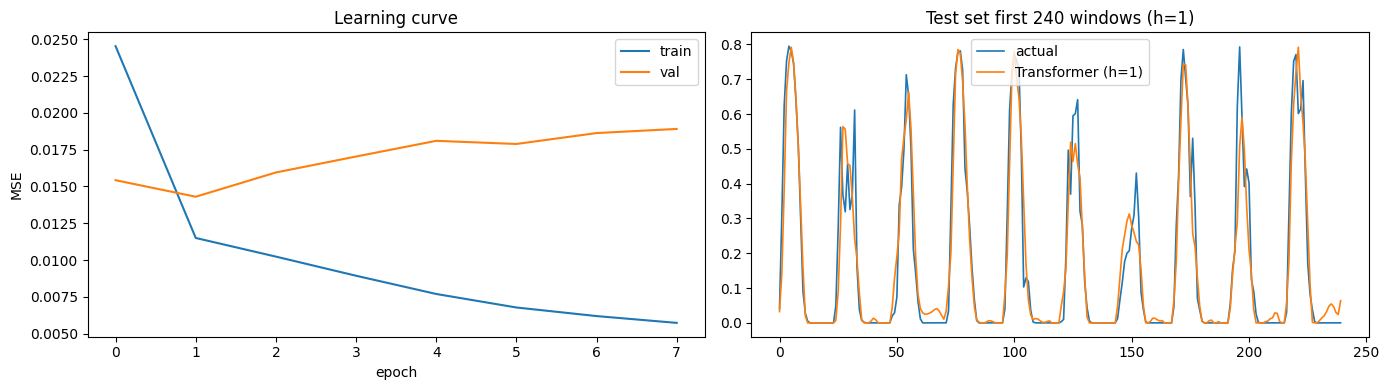

In [7]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

@torch.no_grad()
def predict(dl):
    model.eval()
    out = [model(x.to(device)).cpu().numpy() for x, _ in dl]
    return np.clip(np.concatenate(out), 0, 1)

def true_and_naive(ds):
    true  = np.array([ds.power[s][t:t + ds.H]     for s, t in ds.index])
    naive = np.array([ds.power[s][t - ds.H:t]     for s, t in ds.index])  # same hours, previous day
    return true, naive

pred = predict(test_dl)
true, naive = true_and_naive(test_ds)

def report(name, y, p):
    print(f"{name:<16} RMSE={root_mean_squared_error(y.ravel(), p.ravel()):.4f}  "
          f"MAE={mean_absolute_error(y.ravel(), p.ravel()):.4f}")

print("test set, POWER, full 24h horizon:")
report("Transformer", true, pred)
report("Seasonal-naive", true, naive)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(hist["train"], label="train"); ax[0].plot(hist["val"], label="val")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("MSE"); ax[0].legend(); ax[0].set_title("Learning curve")
ax[1].plot(true[:240, 0], label="actual", lw=1.2)
ax[1].plot(pred[:240, 0], label="Transformer (h=1)", lw=1.2)
ax[1].legend(); ax[1].set_title("Test set first 240 windows (h=1)")
plt.tight_layout(); plt.show()